In [1]:
import polars as pl

In [35]:
train_df = pl.read_csv("../../datasets/google-landmark/raw-csv/train_set.csv")
index_df = pl.read_csv("../../datasets/google-landmark/raw-csv/index_set.csv")

In [23]:
train_geocode = pl.read_csv("../../datasets/google-landmark/raw-csv/train_set_reversed.csv").with_columns(pl.lit("train").alias("src"))
index_geocode = pl.read_csv("../../datasets/google-landmark/raw-csv/index_set_reversed.csv").with_columns(pl.lit("index").alias("src"))

FileNotFoundError: No such file or directory (os error 2): ../../datasets/google-landmark/raw-csv/train_set_reversed.csv

In [ ]:
pl.concat([train_geocode.with_columns(pl.lit("train").alias("src")), index_geocode.with_columns(pl.lit("index").alias("src"))]).write_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/v2/merged_set.csv")

In [24]:
merged_set = pl.read_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/v2/merged_set.csv")
merged_set

id,landmark_id,latitude,longitude,wikimedia_url,geohack_url,country_code,country,region,subregion,src
str,i64,f64,f64,str,str,str,str,str,str,str
"""6e158a47eb2ca3f6""",142820,59.341667,18.054722,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""SE""","""Sweden""","""Europe""","""Northern Europe""","""train"""
"""202cd79556f30760""",104169,56.123889,-3.947778,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""GB""","""United Kingdom""","""Europe""","""Northern Europe""","""train"""
"""3ad87684c99c06e1""",37914,49.202,7.60012,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""DE""","""Germany""","""Europe""","""Western Europe""","""train"""
"""e7f70e9c61e66af3""",102140,3.521642,-76.417036,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""CO""","""Colombia""","""South America""","""South America""","""train"""
"""4072182eddd0100e""",2474,51.685278,-2.543611,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""GB""","""United Kingdom""","""Europe""","""Northern Europe""","""train"""
…,…,…,…,…,…,…,…,…,…,…
"""ace1f52eea7620e9""",1463,53.001714,6.72987,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""NL""","""Netherlands""","""Europe""","""Western Europe""","""index"""
"""f07d97acbc9cac79""",51420,52.377329,4.59569,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""NL""","""Netherlands""","""Europe""","""Western Europe""","""index"""
"""2a2bdc07e5144f71""",27922,17.242778,98.972222,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""TH""","""Thailand""","""Asia""","""South-eastern Asia""","""index"""


In [ ]:
with pl.Config(tbl_cols=-1, tbl_rows=-1):
    display(merged_set.group_by("country").agg(pl.len().alias("count")).sort("count", descending=True))

country,count
str,u32
"""United States""",426551
"""Germany""",349319
"""United Kingdom""",287589
"""France""",214956
"""Italy""",147549
"""Spain""",140034
"""Czechia""",118643
"""Netherlands""",107002
"""Japan""",104844


In [25]:
# Top-5 countries per region
region_country = (
    merged_set
    .filter(pl.col("country").is_not_null() & pl.col("region").is_not_null())
    .group_by(["region", "country"])
    .agg(pl.len().alias("count"))
)

top10_per_region = (
    region_country
    .with_columns(
        pl.col("count").rank("dense", descending=True).over("region").alias("rank")
    )
    .filter(pl.col("rank") <= 10)
    .filter(pl.col("count") >= 45000)
    .sort(["region", "rank"])
)

with pl.Config(tbl_rows=-1):
    display(top10_per_region)

region,country,count,rank
str,str,u32,u32
"""Asia""","""Japan""",104844,1
"""Asia""","""India""",68390,2
"""Asia""","""China""",47570,3
"""Europe""","""Germany""",349319,1
"""Europe""","""United Kingdom""",287589,2
"""Europe""","""France""",214956,3
"""Europe""","""Italy""",147549,4
"""Europe""","""Spain""",140034,5
"""Europe""","""Czechia""",118643,6


In [26]:
top_countries = top10_per_region["country"].to_list()
top_merged_set = merged_set.filter(pl.col("country").is_in(top_countries))

In [40]:
top_merged_set.write_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/v2/merged_set_top_countries.csv")

In [43]:
top_merged_set.sample(100).write_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/v2/merged_set_sample.csv")

In [12]:
preds = pl.read_csv("/tmp/sample_caption_output.csv")
preds.filter(pl.col("pred_label") != "non_landmark").select(["id", "src", "pred_label", "pred_score", "caption"])

id,src,pred_label,pred_score,caption
str,str,str,f64,str
"""f7eb2a6c480fbf97""","""train""","""tower""",0.9,"""A white lighthouse on a sandy …"
"""c85a055b0986f1e1""","""train""","""palace_castle""",0.9,"""A historic stone house with a …"
"""2015fb23bdd66374""","""train""","""arch_gate""",0.9,"""A brick arch gate with the ins…"
"""1a7e39b37cfdab9f""","""train""","""tower""",0.9,"""A tall, white Art Deco buildin…"
"""ab505208130a4f5b""","""train""","""palace_castle""",0.9,"""A picturesque French castle wi…"
…,…,…,…,…
"""285463cbfe879d6d""","""train""","""palace_castle""",0.9,"""A grand red-brick castle with …"
"""634e2d324b9d5fd7""","""train""","""palace_castle""",0.9,"""Ruins of a historic building i…"
"""ed5872e830fdf9d1""","""train""","""bridge""",0.9,"""A bridge with a house in the b…"


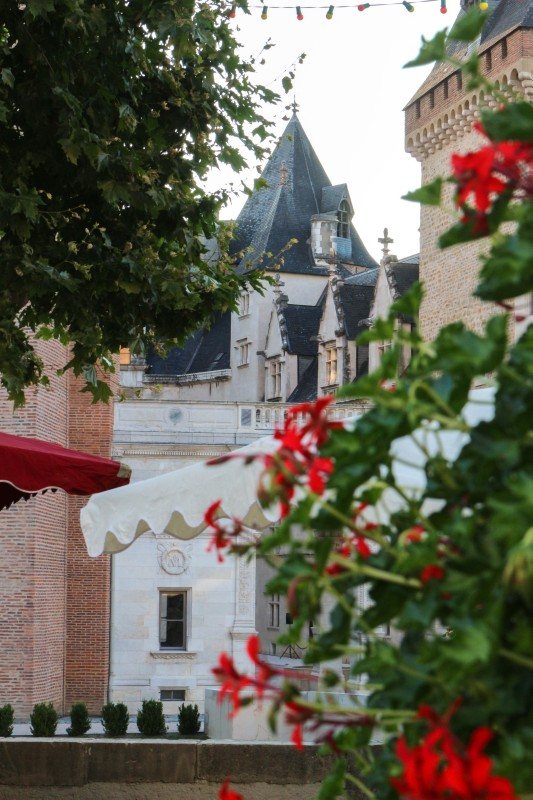

In [15]:
from PIL import Image

Image.open("/mnt/yokoyamalab-nas/gldv2-full/train/ab505208130a4f5b.jpg")

In [27]:
mp16_df = pl.read_csv("/mnt/yokoyamalab-nas/mp16/mp16_reversed.csv")
mp16_df

id,img_path,latitude,longitude,country_code,country,region,subregion
str,str,f64,f64,str,str,str,str
"""b5/e0/5825207952.jpg""","""./images/b5_e0_5825207952.jpg""",46.779843,22.129108,"""RO""","""Romania""","""Europe""","""Eastern Europe"""
"""43/8c/3350940420.jpg""","""./images/43_8c_3350940420.jpg""",37.761501,-122.424003,"""US""","""United States""","""North America""","""Northern America"""
"""ed/2c/8721739032.jpg""","""./images/ed_2c_8721739032.jpg""",45.135253,7.625481,"""IT""","""Italy""","""Europe""","""Southern Europe"""
"""b2/15/5334393895.jpg""","""./images/b2_15_5334393895.jpg""",37.790794,-122.43164,"""US""","""United States""","""North America""","""Northern America"""
"""9b/46/3578976721.jpg""","""./images/9b_46_3578976721.jpg""",28.369822,-81.554351,"""US""","""United States""","""North America""","""Northern America"""
…,…,…,…,…,…,…,…
"""2e/4d/462559192.jpg""","""./images/2e_4d_462559192.jpg""",-8.483578,115.563125,"""ID""","""Indonesia""","""Asia""","""South-eastern Asia"""
"""ac/28/3077185392.jpg""","""./images/ac_28_3077185392.jpg""",37.387489,-5.994468,"""ES""","""Spain""","""Europe""","""Southern Europe"""
"""d9/02/3646415834.jpg""","""./images/d9_02_3646415834.jpg""",-32.494564,137.765024,"""AU""","""Australia""","""Oceania""","""Australia and New Zealand"""


In [29]:
top_mp16_set = mp16_df.filter(pl.col("country").is_in(top_countries))
top_mp16_set

id,img_path,latitude,longitude,country_code,country,region,subregion
str,str,f64,f64,str,str,str,str
"""43/8c/3350940420.jpg""","""./images/43_8c_3350940420.jpg""",37.761501,-122.424003,"""US""","""United States""","""North America""","""Northern America"""
"""ed/2c/8721739032.jpg""","""./images/ed_2c_8721739032.jpg""",45.135253,7.625481,"""IT""","""Italy""","""Europe""","""Southern Europe"""
"""b2/15/5334393895.jpg""","""./images/b2_15_5334393895.jpg""",37.790794,-122.43164,"""US""","""United States""","""North America""","""Northern America"""
"""9b/46/3578976721.jpg""","""./images/9b_46_3578976721.jpg""",28.369822,-81.554351,"""US""","""United States""","""North America""","""Northern America"""
"""c0/28/6717205869.jpg""","""./images/c0_28_6717205869.jpg""",30.695718,-97.196044,"""US""","""United States""","""North America""","""Northern America"""
…,…,…,…,…,…,…,…
"""f8/62/4343249100.jpg""","""./images/f8_62_4343249100.jpg""",13.212665,77.439107,"""IN""","""India""","""Asia""","""Southern Asia"""
"""16/fd/5538692032.jpg""","""./images/16_fd_5538692032.jpg""",45.397636,10.899531,"""IT""","""Italy""","""Europe""","""Southern Europe"""
"""40/b3/4485932631.jpg""","""./images/40_b3_4485932631.jpg""",40.749439,14.003738,"""IT""","""Italy""","""Europe""","""Southern Europe"""


In [30]:
top_mp16_set.write_csv("/mnt/yokoyamalab-nas/mp16/csv/v1/mp16_set_top_countries.csv")

In [33]:
top_mp16_set.with_columns([pl.col("id").alias("id_ori"), pl.col("img_path").alias("id")]).write_csv("/mnt/yokoyamalab-nas/mp16/csv/v1/mp16_set_top_countries.csv")

In [59]:
pl.read_csv("../../datasets/google-landmark/raw-csv/train_label_to_category.csv")

landmark_id,category
i64,str
0,"""http://commons.wikimedia.org/w…"
1,"""http://commons.wikimedia.org/w…"
2,"""http://commons.wikimedia.org/w…"
3,"""http://commons.wikimedia.org/w…"
4,"""http://commons.wikimedia.org/w…"
…,…
203089,"""http://commons.wikimedia.org/w…"
203090,"""http://commons.wikimedia.org/w…"
203091,"""http://commons.wikimedia.org/w…"


In [63]:
gldv_train_latlon = pl.read_csv("../../datasets/google-landmark/raw-csv/train_category_w_latlon.csv")
gldv_train_latlon

id,landmark_id,input_url,resolved_url,geohack_url,latitude,longitude,error
str,i64,str,str,str,f64,f64,str
null,20,"""http://commons.wikimedia.org/w…",null,null,null,null,"""Client error '404 Not Found' f…"
null,39,"""http://commons.wikimedia.org/w…",null,null,null,null,"""Client error '404 Not Found' f…"
null,0,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",22.2728,114.182,null
null,2,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",47.959444,6.925556,null
null,4,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",41.895917,12.5005,null
…,…,…,…,…,…,…,…
null,203063,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",58.535961,31.276131,null
null,203069,"""http://commons.wikimedia.org/w…",null,null,null,null,"""No GeoHack coordinates found a…"
null,203074,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",50.181104,-5.070283,null


In [71]:
gldv_train = pl.read_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/train_reversed.csv")
gldv_train

id,url,landmark_id,input_url,resolved_url,geohack_url,latitude,longitude,error,country_code,country,region,subregion
str,str,i64,str,str,str,f64,f64,str,str,str,str,str
"""6e158a47eb2ca3f6""","""https://upload.wikimedia.org/w…",142820,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",59.341667,18.054722,null,"""SE""","""Sweden""","""Europe""","""Northern Europe"""
"""202cd79556f30760""","""http://upload.wikimedia.org/wi…",104169,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",56.123889,-3.947778,null,"""GB""","""United Kingdom""","""Europe""","""Northern Europe"""
"""3ad87684c99c06e1""","""http://upload.wikimedia.org/wi…",37914,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",49.202,7.60012,null,"""DE""","""Germany""","""Europe""","""Western Europe"""
"""e7f70e9c61e66af3""","""https://upload.wikimedia.org/w…",102140,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",3.521642,-76.417036,null,"""CO""","""Colombia""","""South America""","""South America"""
"""4072182eddd0100e""","""https://upload.wikimedia.org/w…",2474,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",51.685278,-2.543611,null,"""GB""","""United Kingdom""","""Europe""","""Northern Europe"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""fc0f007893b11ba7""","""https://upload.wikimedia.org/w…",172138,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",32.641861,34.924222,null,"""IL""","""Israel""","""Asia""","""Western Asia"""
"""39aad18585867916""","""https://upload.wikimedia.org/w…",162860,"""http://commons.wikimedia.org/w…",null,null,null,null,"""Client error '429 Too Many Req…",null,null,null,null
"""fd0725460e4ebbec""","""https://upload.wikimedia.org/w…",191243,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",69.64807,18.9874,null,"""NO""","""Norway""","""Europe""","""Northern Europe"""


In [86]:
gldv_index = pl.read_csv("/home/affahrizain/Desktop/index_image_to_landmark.csv")
gldv_index

id,landmark_id
str,i64
"""fdf40612109ad174""",32888
"""5a6cc67c893daea6""",552
"""87b88acb68cdc1f1""",13626
"""c4ac217ce087b251""",8699
"""05f269bf32be9d3e""",30838
…,…
"""03947beda4345d37""",16254
"""5c11122e655fdf4e""",86165
"""9fff2d3c31495fa5""",48911


In [115]:
gldv_index_latlon = pl.read_csv("/home/affahrizain/Desktop/index_label_to_category_latlon.csv")
gldv_index_latlon

id,landmark_id,input_url,resolved_url,geohack_url,latitude,longitude,error
str,i64,str,str,str,f64,f64,str
null,45,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",49.00767,12.379459,null
null,47,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",60.81051,21.447125,null
null,48,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",36.05686,120.33597,null
null,9,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",62.563056,28.790556,null
null,13,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",46.140577,14.396925,null
…,…,…,…,…,…,…,…
null,101198,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",41.381483,1.795853,null
null,101206,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",44.765707,20.453362,null
null,101218,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",29.962597,121.345725,null


In [112]:
gldv_index_latlon.filter(pl.col("error").str.contains("429"))

id,landmark_id,input_url,resolved_url,geohack_url,latitude,longitude,error
str,i64,str,str,str,f64,f64,str
null,2076,"""http://commons.wikimedia.org/w…",null,null,null,null,"""Client error '429 Too Many Req…"
null,2280,"""http://commons.wikimedia.org/w…",null,null,null,null,"""Client error '429 Too Many Req…"
null,2286,"""http://commons.wikimedia.org/w…",null,null,null,null,"""Client error '429 Too Many Req…"
null,2291,"""http://commons.wikimedia.org/w…",null,null,null,null,"""Client error '429 Too Many Req…"
null,2209,"""http://commons.wikimedia.org/w…",null,null,null,null,"""Client error '429 Too Many Req…"
…,…,…,…,…,…,…,…
null,101109,"""http://commons.wikimedia.org/w…",null,null,null,null,"""Client error '429 Too Many Req…"
null,101120,"""http://commons.wikimedia.org/w…",null,null,null,null,"""Client error '429 Too Many Req…"
null,101122,"""http://commons.wikimedia.org/w…",null,null,null,null,"""Client error '429 Too Many Req…"


In [113]:
gldv_index_latlon.filter(~pl.col("error").str.contains("429") | pl.col("error").is_null())#.write_csv("/home/affahrizain/Desktop/index_label_to_category_latlon.csv")

id,landmark_id,input_url,resolved_url,geohack_url,latitude,longitude,error
str,i64,str,str,str,f64,f64,str
null,45,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",49.00767,12.379459,null
null,47,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",60.81051,21.447125,null
null,48,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",36.05686,120.33597,null
null,9,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",62.563056,28.790556,null
null,13,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",46.140577,14.396925,null
…,…,…,…,…,…,…,…
null,101198,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",41.381483,1.795853,null
null,101206,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",44.765707,20.453362,null
null,101218,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",29.962597,121.345725,null


In [125]:
gldv_merged = pl.read_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/v2/merged_set_top_countries_caption_labels.csv")
gldv_merged
# gldv_merged.filter(pl.col("pred_label") != "non_landmark")
# with pl.Config(tbl_cols=-1, tbl_rows=-1):
    # display(gldv_merged.filter(pl.col("pred_label") != "non_landmark").group_by("country").agg(pl.len().alias("total")).sort("total", descending=True))

id,landmark_id,latitude,longitude,wikimedia_url,geohack_url,country_code,country,region,subregion,src,pred_label,pred_score,caption
str,i64,f64,f64,str,str,str,str,str,str,str,str,f64,str
"""4b966789e0572456""",30319,52.226169,21.023186,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""PL""","""Poland""","""Europe""","""Eastern Europe""","""train""","""palace_castle""",0.9,"""Classical European building wi…"
"""16d8aa057cdd01b9""",25719,45.58359,9.27567,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""IT""","""Italy""","""Europe""","""Southern Europe""","""train""","""non_landmark""",0.9,"""Information board with text an…"
"""f1556e1eeeba213f""",36639,44.0446,-74.9325,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""US""","""United States""","""North America""","""Northern America""","""train""","""non_landmark""",0.9,"""A small green plant growing on…"
"""4072182eddd0100e""",2474,51.685278,-2.543611,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""GB""","""United Kingdom""","""Europe""","""Northern Europe""","""train""","""non_landmark""",0.9,"""A serene stream flowing throug…"
"""3cdc355c6232712f""",12877,48.862444,2.395889,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""FR""","""France""","""Europe""","""Western Europe""","""train""","""non_landmark""",0.9,"""A memorial wall with numerous …"
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""50792ccf8cf91575""",93260,22.2097,-159.477,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""US""","""United States""","""North America""","""Northern America""","""index""","""non_landmark""",0.7,"""Historical street scene with b…"
"""1ded247f2ea76eea""",69456,38.890444,-77.069722,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""US""","""United States""","""North America""","""Northern America""","""index""","""monument_statue""",0.9,"""A bronze statue of soldiers on…"
"""c13699e76340d47a""",22783,63.474167,-150.875833,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""US""","""United States""","""North America""","""Northern America""","""index""","""non_landmark""",0.9,"""A small airplane flying over a…"


In [124]:
gldv_merged

id,landmark_id,latitude,longitude,wikimedia_url,geohack_url,country_code,country,region,subregion,src,pred_label,pred_score,caption
str,i64,f64,f64,str,str,str,str,str,str,str,str,f64,str
"""4b966789e0572456""",30319,52.226169,21.023186,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""PL""","""Poland""","""Europe""","""Eastern Europe""","""train""","""palace_castle""",0.9,"""Classical European building wi…"
"""16d8aa057cdd01b9""",25719,45.58359,9.27567,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""IT""","""Italy""","""Europe""","""Southern Europe""","""train""","""non_landmark""",0.9,"""Information board with text an…"
"""f1556e1eeeba213f""",36639,44.0446,-74.9325,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""US""","""United States""","""North America""","""Northern America""","""train""","""non_landmark""",0.9,"""A small green plant growing on…"
"""4072182eddd0100e""",2474,51.685278,-2.543611,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""GB""","""United Kingdom""","""Europe""","""Northern Europe""","""train""","""non_landmark""",0.9,"""A serene stream flowing throug…"
"""3cdc355c6232712f""",12877,48.862444,2.395889,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""FR""","""France""","""Europe""","""Western Europe""","""train""","""non_landmark""",0.9,"""A memorial wall with numerous …"
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""c239fe9d43ff0cd7""",107893,50.3317,7.90472,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""DE""","""Germany""","""Europe""","""Western Europe""","""train""","""tower""",0.9,"""A stone tower with a staircase…"
"""b2b4e9c0791788b8""",140192,52.202556,4.3925,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""NL""","""Netherlands""","""Europe""","""Western Europe""","""train""","""non_landmark""",0.9,"""A historic church with a tall …"
"""eee4caa8c8b14928""",951,48.1136,11.6381,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""DE""","""Germany""","""Europe""","""Western Europe""","""train""","""non_landmark""",0.7,"""A serene lakeside with a red-r…"


In [118]:
train_df = pl.read_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/v2/temp/train.csv")
valid_df = pl.read_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/v2/temp/valid.csv")
test_df = pl.read_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/v2/temp/test.csv")

In [120]:
pl.concat([train_df, valid_df, test_df]).select(["id", "src"])

id,src
str,str
"""3f74003c5b060613""","""train"""
"""774a5eff9f01d1b3""","""train"""
"""91b70d0274d7e4a9""","""train"""
"""3111f4eeebd4e15e""","""train"""
"""1a10c0d307cf3e03""","""train"""
…,…
"""4f919fd72814dcc4""","""train"""
"""c6252911db901004""","""train"""
"""b0920dabb0b91a6b""","""train"""


In [122]:
IMG_ROOT = "/mnt/yokoyamalab-nas/gldv2-full"
FILE_LIST_DIR = "/mnt/yokoyamalab-nas/gldv2-full/csv/v2/temp"

df = pl.concat([train_df, valid_df, test_df]).select(["id", "src"])

for src, group in df.group_by("src"):
    src = src[0]
    # relative paths → tar preserves train/ or index/ folder on extract
    paths = [f"{src}/{id_}.jpg" for id_ in group["id"].to_list()]
    list_path = f"{FILE_LIST_DIR}/{src}_filelist.txt"
    with open(list_path, "w") as f:
        f.write("\n".join(paths))
    print(f"Written {len(paths):,} paths → {list_path}")

print(f"\nRun these to bundle and split into 20GB chunks:")
for src in df["src"].unique().to_list():
    list_path = f"{FILE_LIST_DIR}/{src}_filelist.txt"
    out_prefix = f"{FILE_LIST_DIR}/gldv2_{src}.tar.part_"
    print(f"\n  # {src}")
    print(f"  tar -cf - -C {IMG_ROOT} --files-from={list_path} | split -b 20G - {out_prefix}")

print(f"\nUpload with rclone:")
print(f"  rclone copy {FILE_LIST_DIR} onedrive:gldv2/ --include '*.tar.part_*' --transfers 4 --progress")

Written 456,629 paths → /mnt/yokoyamalab-nas/gldv2-full/csv/v2/temp/train_filelist.txt

Run these to bundle and split into 20GB chunks:

  # train
  tar -cf - -C /mnt/yokoyamalab-nas/gldv2-full --files-from=/mnt/yokoyamalab-nas/gldv2-full/csv/v2/temp/train_filelist.txt | split -b 20G - /mnt/yokoyamalab-nas/gldv2-full/csv/v2/temp/gldv2_train.tar.part_

Upload with rclone:
  rclone copy /mnt/yokoyamalab-nas/gldv2-full/csv/v2/temp onedrive:gldv2/ --include '*.tar.part_*' --transfers 4 --progress


In [ ]:
tar -cf - -C /mnt/yokoyamalab-nas/gldv2-full --files-from=train_filelist.txt | pv | split -b 20G - /mnt/yokoyamalab-nas/gldv2-full/csv/v2/temp/gldv2_train.tar.part_

In [128]:
v1_train = pl.read_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/v1/merged_set_train.csv")
v1_index = pl.read_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/v1/merged_set_index.csv")

In [131]:
IMG_ROOT = "/mnt/yokoyamalab-nas/gldv2-full"
FILE_LIST_DIR = "/mnt/yokoyamalab-nas/gldv2-full/csv/v1"

df = pl.concat([v1_train, v1_index]).select(["id", "folder"])

for src, group in df.group_by("folder"):
    src = src[0]
    # relative paths → tar preserves train/ or index/ folder on extract
    paths = [f"{src}/{id_}.jpg" for id_ in group["id"].to_list()]
    list_path = f"{FILE_LIST_DIR}/{src}_filelist.txt"
    with open(list_path, "w") as f:
        f.write("\n".join(paths))
    print(f"Written {len(paths):,} paths → {list_path}")

print(f"\nRun these to bundle and split into 20GB chunks:")
for src in df["folder"].unique().to_list():
    list_path = f"{FILE_LIST_DIR}/{src}_filelist.txt"
    out_prefix = f"{FILE_LIST_DIR}/gldv2_{src}.tar.part_"
    print(f"\n  # {src}")
    print(f"  tar -cf - -C {IMG_ROOT} --files-from={list_path} | split -b 20G - {out_prefix}")

print(f"\nUpload with rclone:")
print(f"  rclone copy {FILE_LIST_DIR} onedrive:gldv2/ --include '*.tar.part_*' --transfers 4 --progress")

Written 16,074 paths → /mnt/yokoyamalab-nas/gldv2-full/csv/v1/train_filelist.txt
Written 2,672 paths → /mnt/yokoyamalab-nas/gldv2-full/csv/v1/index_filelist.txt

Run these to bundle and split into 20GB chunks:

  # index
  tar -cf - -C /mnt/yokoyamalab-nas/gldv2-full --files-from=/mnt/yokoyamalab-nas/gldv2-full/csv/v1/index_filelist.txt | split -b 20G - /mnt/yokoyamalab-nas/gldv2-full/csv/v1/gldv2_index.tar.part_

  # train
  tar -cf - -C /mnt/yokoyamalab-nas/gldv2-full --files-from=/mnt/yokoyamalab-nas/gldv2-full/csv/v1/train_filelist.txt | split -b 20G - /mnt/yokoyamalab-nas/gldv2-full/csv/v1/gldv2_train.tar.part_

Upload with rclone:
  rclone copy /mnt/yokoyamalab-nas/gldv2-full/csv/v1 onedrive:gldv2/ --include '*.tar.part_*' --transfers 4 --progress


In [3]:
captions = pl.read_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/v1/merged_set_train_labels.csv")["caption"].to_list()
captions[:5]

['A tall, red sandstone tower viewed through an archway in India, showcasing intricate brickwork and historical architecture.',
 'Two modern high-rise buildings under construction in Bahrain, with clear blue sky and parked cars in the foreground.',
 'A large, historic hotel with multiple towers and steep roofs, surrounded by dense green forest in the Canadian Rockies.',
 'White clock tower with a red dome, located in a city square with trees and parked cars, in Malaysia.',
 'A historic stone building with blue doors, surrounded by trees and a clear blue sky, located in Australia.']

In [4]:
from transformers import AutoProcessor, AutoTokenizer
import sys
sys.path.append("..")
from src.geotir.train import CLIP_MODEL_NAME

tokenizer = AutoTokenizer.from_pretrained(CLIP_MODEL_NAME)

In [13]:
tokenized = tokenizer(
    captions,
    # truncation=True,
    # padding="max_length",
    # max_length=77,
    # return_tensors="pt"
)

In [14]:
lengths = []
for i in tokenized["input_ids"]:
    lengths.append(len(i))

In [15]:
max(lengths)

66